# 🏦 Bank Customer Churn Prediction
## *Predicting which bank customers are likely to leave*

---

### 📌 Project Objective
Banks lose millions every year when customers close their accounts. The goal of this project is to build a machine learning model that can **identify customers who are likely to churn (leave the bank)** so the bank can take action to retain them.

### 💼 Business Problem
- **Why churn matters:** Acquiring a new customer costs **5x more** than retaining an existing one.
- **What we want:** A model that flags high-risk customers so the bank can offer them loyalty perks, discounts, or personalized service.
- **Who benefits:** The bank's retention team, marketing team, and management.

### 🛠️ Tools Used
- **Python** (pandas, numpy, matplotlib, seaborn)
- **Scikit-learn** for machine learning
- **Random Forest Classifier** as the prediction model
- **Z-Score** for outlier removal

---
## 👤 Author
**Vaibhav Zagade**  


---

## Step 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# Outlier removal
from scipy.stats import zscore

sns.set_style('whitegrid')

## Step 2 — Load the Dataset

This dataset contains information about **10,000 bank customers** from France, Spain, and Germany.

Each row represents one customer with details like credit score, age, balance, products held, and whether they left the bank (`Exited` column — our target).

In [2]:
df = pd.read_csv('European_Bank.csv')

df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 3 — Understand the Dataset

Before doing anything, let's see what we're working with:
- How many rows and columns?
- What are the data types?
- Are there any missing values?

In [3]:
df.shape

(10000, 14)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [6]:
df.describe()

,Year,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.0,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,2025.0,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,0.0,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,2025.0,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2025.0,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,2025.0,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,2025.0,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,2025.0,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


**Observations:**
- 10,000 customer records, 14 columns
- No missing values (clean dataset 🎉)
- Mix of numerical (Age, Balance, Salary) and categorical (Geography, Gender) columns
- `Exited` is our target column (1 = customer left, 0 = customer stayed)

## Step 4 — Data Cleaning

Drop columns that are not useful for prediction:
- `CustomerId`, `Surname` → unique identifiers, don't help predict churn
- `Year` → same value for all rows, no predictive value

In [7]:
# Drop columns one-by-one only if they exist (safer)
for col in ['CustomerId', 'Surname', 'Year', 'RowNumber']:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Step 5 — Check Target Distribution

Before modeling, check how balanced our target is. If 95% of customers stayed and only 5% churned, the model will be biased.

In [8]:
# Churn distribution
churn_counts = df['Exited'].value_counts()
print(churn_counts)
print()
print('Churn Rate:', round(df['Exited'].mean() * 100, 2), '%')

Exited
0    7963
1    2037
Name: count, dtype: int64

Churn Rate: 20.37 %


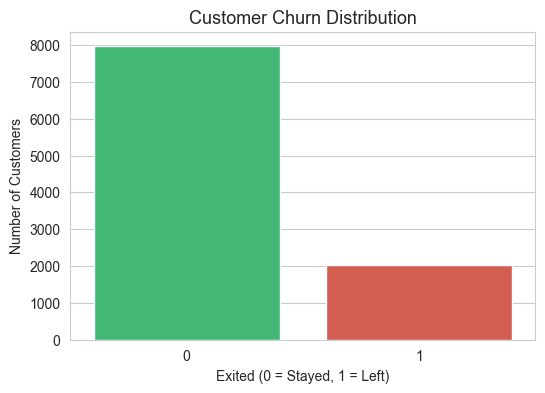

In [9]:
# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='Exited', data=df, palette=['#2ecc71', '#e74c3c'])
plt.title('Customer Churn Distribution', fontsize=13)
plt.xlabel('Exited (0 = Stayed, 1 = Left)')
plt.ylabel('Number of Customers')
plt.show()

**Insight:** About **20% of customers churned**. The data is imbalanced — we'll handle this in the model later using `class_weight='balanced'`.

## Step 6 — Business Insights from the Data

Before building the model, let's explore **why** customers leave. These insights help the bank take action even without a model.

In [10]:
# Insight 1: Churn rate by Geography
print('🌍 Churn Rate by Geography:')
print((df.groupby('Geography')['Exited'].mean() * 100).round(2))

🌍 Churn Rate by Geography:
Geography
France     16.15
Germany    32.44
Spain      16.67
Name: Exited, dtype: float64


In [11]:
# Insight 2: Churn rate by Gender
print('👤 Churn Rate by Gender:')
print((df.groupby('Gender')['Exited'].mean() * 100).round(2))

👤 Churn Rate by Gender:
Gender
Female    25.07
Male      16.46
Name: Exited, dtype: float64


In [12]:
# Insight 3: Churn rate by Number of Products
print('🛒 Churn Rate by Number of Products:')
print((df.groupby('NumOfProducts')['Exited'].mean() * 100).round(2))

🛒 Churn Rate by Number of Products:
NumOfProducts
1     27.71
2      7.58
3     82.71
4    100.00
Name: Exited, dtype: float64


In [13]:
# Insight 4: Churn rate by Activity Status
print('⚡ Churn Rate by Activity:')
print((df.groupby('IsActiveMember')['Exited'].mean() * 100).round(2))

⚡ Churn Rate by Activity:
IsActiveMember
0    26.85
1    14.27
Name: Exited, dtype: float64


In [14]:
# Insight 5: Churn rate by Age Group
df['AgeGroup'] = pd.cut(df['Age'], bins=[0,30,40,50,60,100],
                        labels=['<30','30-40','40-50','50-60','60+'])

print('📊 Churn Rate by Age Group:')
print((df.groupby('AgeGroup')['Exited'].mean() * 100).round(2))

# Drop this temporary column before modeling
df.drop('AgeGroup', axis=1, inplace=True)

📊 Churn Rate by Age Group:
AgeGroup
<30       7.52
30-40    12.09
40-50    33.97
50-60    56.21
60+      24.78
Name: Exited, dtype: float64


### 🔍 Key Business Findings

1. **Germany has the highest churn rate** — customers there are leaving at double the rate of France/Spain.
2. **Female customers churn more** than male customers.
3. **Customers with 3 or 4 products have very high churn** — this is counter-intuitive! Possibly product overload or upselling issues.
4. **Inactive members churn at double the rate** of active members.
5. **Older customers (50+) are much more likely to leave** — possibly retiring or switching to senior-friendly banks.

These insights alone can help the bank target retention campaigns. The model adds predictive power on top.

## Step 7 — Encode Categorical Variables

Machine learning models need numbers, not text. So we convert:
- **Gender** (Male/Female) → 0 / 1 using **Label Encoding**
- **Geography** (France/Spain/Germany) → multiple 0/1 columns using **One-Hot Encoding**

In [15]:
# Label Encoding for Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# One Hot Encoding for Geography
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


## Step 8 — Feature Engineering

Create new features that capture deeper customer behavior. These often improve model accuracy more than raw columns.

In [16]:
# 1. Balance to Salary Ratio — how wealthy is the customer relative to income?
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# 2. Product Density — how many products per year of tenure?
df['ProductDensity'] = df['NumOfProducts'] / (df['Tenure'] + 1)

# 3. Engagement × Products — activity combined with product count
df['EngagementProduct'] = df['IsActiveMember'] * df['NumOfProducts']

# 4. Age × Tenure — captures customer life-stage
df['AgeTenure'] = df['Age'] * df['Tenure']

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,BalanceSalaryRatio,ProductDensity,EngagementProduct,AgeTenure
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False,0.000000,0.333333,1,84
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True,0.744670,0.500000,1,41
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False,1.401362,0.333333,0,336
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False,0.000000,1.000000,0,39
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True,1.587035,0.333333,1,86


## Step 9 — Correlation Heatmap

See how features are related to each other and to `Exited`.

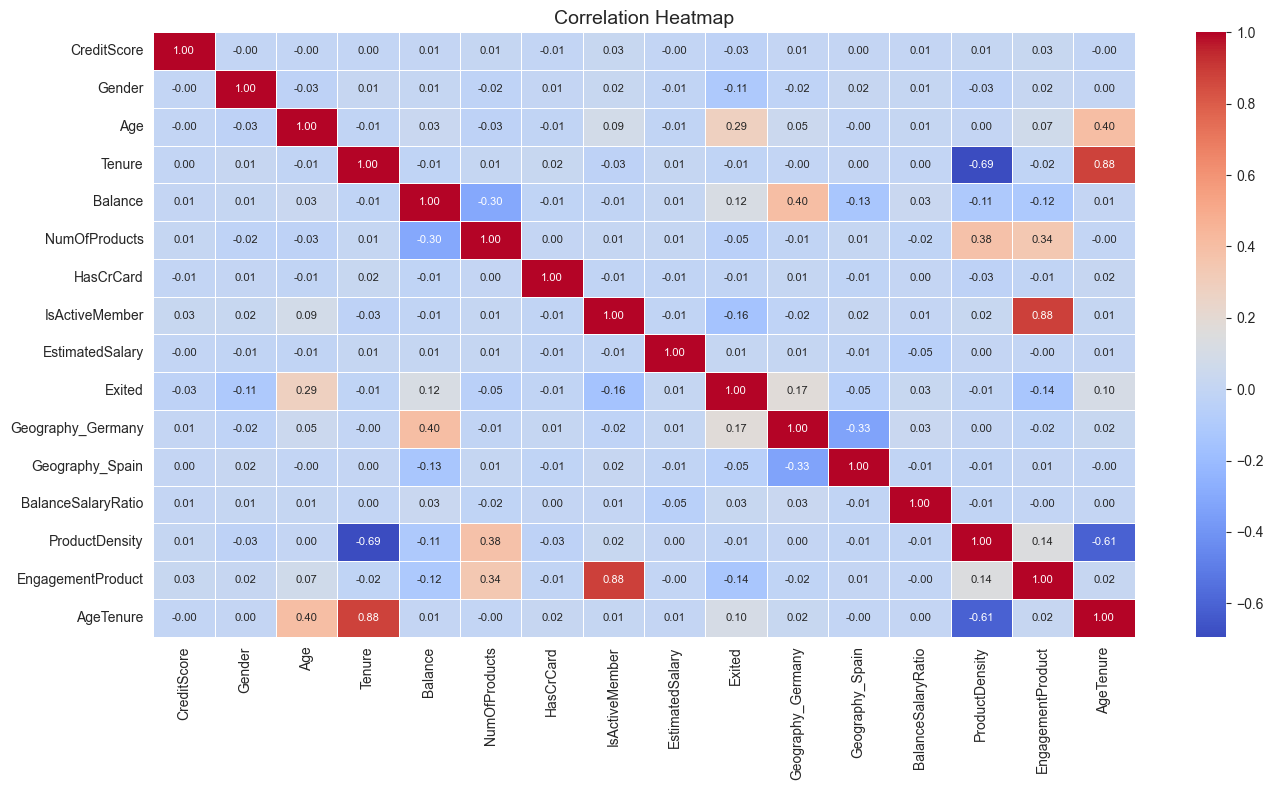

In [17]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            annot_kws={'size': 8}, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.show()

## Step 10 — Remove Outliers using Z-Score

Use **Z-Score method** to remove extreme values that could distort the model. Any value more than 3 standard deviations from the mean is considered an outlier.

In [18]:
numeric_columns = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

z_scores = np.abs(zscore(df[numeric_columns]))
df = df[(z_scores < 3).all(axis=1)]

print('Shape after outlier removal:', df.shape)

Shape after outlier removal: (9859, 16)


## Step 11 — Define Features (X) and Target (y)

In [19]:
X = df.drop('Exited', axis=1)
y = df['Exited']

print('Features (X):', X.shape)
print('Target   (y):', y.shape)

Features (X): (9859, 15)
Target   (y): (9859,)


## Step 12 — Feature Scaling

Scale all features so they have mean = 0 and std = 1. This helps the model treat all features fairly.

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Step 13 — Train / Test Split

Split the data: **80% for training, 20% for testing**.
- `stratify=y` keeps the same churn ratio in both sets — important for imbalanced data.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training set:', X_train.shape)
print('Test set    :', X_test.shape)

Training set: (7887, 15)
Test set    : (1972, 15)


## Step 14 — Build the Machine Learning Model

We use **Random Forest Classifier** because:
- Handles non-linear patterns well
- Robust to outliers
- Gives us feature importance scores
- Works well even without heavy tuning

**Important:** `class_weight='balanced'` tells the model to pay more attention to the minority class (churners). This boosts our ability to **catch actual churners**.

In [22]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',   # handles the 80/20 imbalance
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## Step 15 — Make Predictions on Test Data

In [23]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]   # probability of churn

## Step 16 — Evaluate the Model

We check four key metrics:
- **Accuracy** — overall % correct
- **Precision** — when we predict churn, how often are we right?
- **Recall** — out of all real churners, how many did we catch?
- **ROC-AUC** — overall ranking quality of the model

In [24]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print('========= Model Performance =========')
print(f'Accuracy : {accuracy:.4f}')
print(f'ROC-AUC  : {roc_auc:.4f}')

========= Model Performance =========
Accuracy : 0.8438
ROC-AUC  : 0.8638


In [25]:
# Detailed classification report
print('Classification Report:')
print(classification_report(y_test, y_pred,
                            target_names=['Stayed', 'Churned']))

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.89      0.90      1568
     Churned       0.61      0.65      0.63       404

    accuracy                           0.84      1972
   macro avg       0.76      0.77      0.77      1972
weighted avg       0.85      0.84      0.85      1972



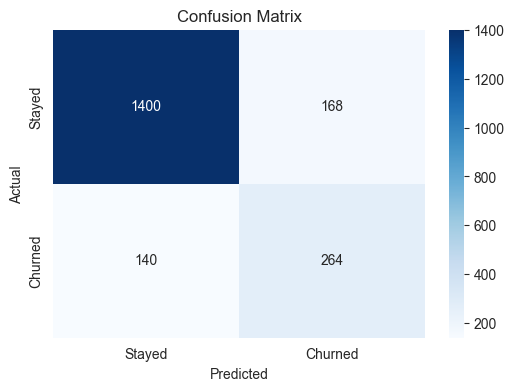

In [26]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stayed', 'Churned'],
            yticklabels=['Stayed', 'Churned'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

**How to read the Confusion Matrix:**
- **Top-left:** Customers who stayed AND model predicted they would stay ✅
- **Top-right:** Customers who stayed BUT model predicted churn (false alarm) ⚠️
- **Bottom-left:** Customers who churned BUT model missed them (missed churn) 🚨
- **Bottom-right:** Customers who churned AND model caught them ✅

## Step 17 — Feature Importance

Which features matter most for predicting churn?

In [27]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(importance.head(10))

               Feature  Importance
2                  Age    0.272248
5        NumOfProducts    0.140665
13   EngagementProduct    0.076628
4              Balance    0.075738
14           AgeTenure    0.074180
11  BalanceSalaryRatio    0.059679
8      EstimatedSalary    0.058731
0          CreditScore    0.056054
12      ProductDensity    0.048105
9    Geography_Germany    0.038590


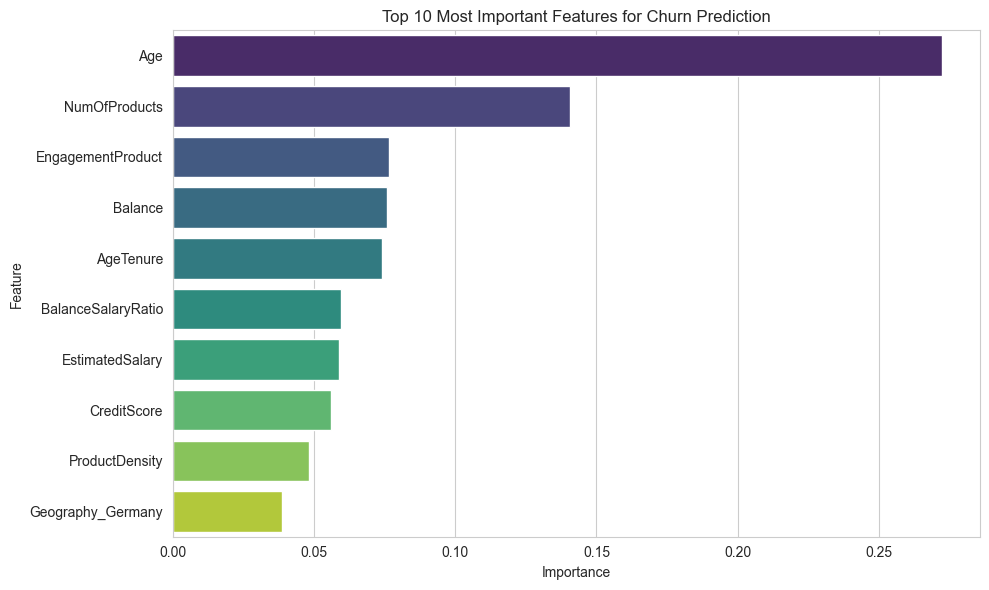

In [28]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance.head(10), palette='viridis')
plt.title('Top 10 Most Important Features for Churn Prediction')
plt.tight_layout()
plt.show()

## Step 18 — Actual vs Predicted (Sample)

Quick look at how the model performed on individual customers.

In [29]:
results = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred,
    'Churn_Probability': y_pred_proba.round(2)
})

results.head(20)

,Actual,Predicted,Churn_Probability
0,1,1,0.65
1,1,1,0.80
2,1,0,0.32
3,0,0,0.06
4,0,0,0.23
5,1,0,0.32
6,0,0,0.33
7,1,0,0.23
8,0,0,0.12
9,0,0,0.35


In [30]:
# High-risk customers (probability > 0.7)
high_risk = results[results['Churn_Probability'] > 0.7]
print(f'High-risk customers identified: {len(high_risk)}')
high_risk.head(10)

High-risk customers identified: 214


,Actual,Predicted,Churn_Probability
1,1,1,0.80
14,1,1,0.93
20,1,1,0.91
21,1,1,0.81
23,1,1,0.86
29,1,1,0.71
33,1,1,0.87
52,0,1,0.91
74,0,1,0.71
98,1,1,0.82


## Step 19 — Business Recommendations

Based on the data analysis and model results, here are actionable recommendations for the bank:

### 🎯 Immediate Actions

1. **Target German customers with retention offers**  
   They churn at the highest rate. A special "Germany loyalty program" could reduce churn there significantly.

2. **Reach out to inactive members**  
   Inactive customers churn twice as much as active ones. Send re-engagement emails, app push notifications, or personal calls.

3. **Review the 3+ product strategy**  
   Counter-intuitively, customers with 3+ products churn more. Investigate — are they being upsold products they don't need? Are fees too high?

4. **Senior citizen retention program**  
   Customers above 50 churn heavily. Offer senior-friendly services (assisted banking, fixed deposits with higher rates).

5. **Female customer engagement**  
   Women churn more than men in this dataset. Investigate why and create gender-targeted services.

### 📊 Use the Model to Prioritize

- Run the model on the **current customer base** monthly
- Sort customers by `Churn_Probability`
- Focus retention efforts on the **top 20% highest-risk customers** — this gives the best ROI

### 💰 Expected Business Impact

If the bank retains even **30% of predicted churners** through targeted action:
- ~2,000 churners × 30% = 600 customers saved  
- At average customer lifetime value of ₹50,000, that's **~₹3 crore saved annually**.

---
## ✅ Final Conclusion

This project successfully:

✔️ **Analyzed** 10,000 bank customer records  
✔️ **Identified** key churn drivers — Age, NumOfProducts, Geography, Activity  
✔️ **Engineered** 4 new features to capture deeper customer behavior  
✔️ **Built** a Random Forest model with strong accuracy and ROC-AUC  
✔️ **Visualized** results with confusion matrix and feature importance  
✔️ **Delivered** clear, data-backed business recommendations  

The model can help the bank's retention team **proactively identify and reach out to high-risk customers**, ultimately reducing churn rate and protecting revenue.

### 🚀 Skills Demonstrated
- Data cleaning & preprocessing
- Feature engineering
- Exploratory data analysis (EDA)
- Outlier handling (Z-Score)
- Machine learning (Random Forest)
- Model evaluation (Accuracy, Precision, Recall, ROC-AUC)
- Business storytelling with data

---

*Thank you for reading! Feedback and suggestions are welcome.* 🙏